In [56]:
# Data manipulation and analysis
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning - Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA

# Machine Learning - Models
from sklearn.ensemble import RandomForestClassifier, IsolationForest, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# Machine Learning - Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
plt.style.use('ggplot')

print("All libraries imported successfully!")

All libraries imported successfully!


# =====================================================================
# PREPROCESSING
# =====================================================================

## Step 1: Handling Identifier and Temporal Columns

In [57]:
# Load the dataset
df = pd.read_csv('/Users/ayoubkallel/PFA2/-Intelligent-Anomaly-Monitoring-in-5G-networks/Data/Model_data.csv')

# Convert timestamp column to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

print("✅ Dataset loaded successfully!")
print(f"📊 Dataset dimensions: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"📅 Period covered: {df['timestamp'].min()} to {df['timestamp'].max()}")

✅ Dataset loaded successfully!
📊 Dataset dimensions: 210,528 rows × 23 columns
📅 Period covered: 2024-01-01 00:00:23 to 2025-12-31 23:55:00


In [58]:
# =====================================================================
# 1.1 Extract temporal components from timestamp
# =====================================================================

df['year']   = df['timestamp'].dt.year
df['month']  = df['timestamp'].dt.month
df['day']    = df['timestamp'].dt.day
df['hour']   = df['timestamp'].dt.hour
df['minute'] = df['timestamp'].dt.minute
df['second'] = df['timestamp'].dt.second
df['date'] = df['timestamp'].dt.date

print("Temporal columns extracted:")
print(df[['timestamp', 'year', 'month', 'day', 'hour', 'minute', 'second']].head(10))

Temporal columns extracted:
            timestamp  year  month  day  hour  minute  second
0 2024-01-01 00:00:23  2024      1    1     0       0      23
1 2024-01-01 00:05:07  2024      1    1     0       5       7
2 2024-01-01 00:10:21  2024      1    1     0      10      21
3 2024-01-01 00:14:31  2024      1    1     0      14      31
4 2024-01-01 00:20:09  2024      1    1     0      20       9
5 2024-01-01 00:24:30  2024      1    1     0      24      30
6 2024-01-01 00:30:07  2024      1    1     0      30       7
7 2024-01-01 00:34:43  2024      1    1     0      34      43
8 2024-01-01 00:39:56  2024      1    1     0      39      56
9 2024-01-01 00:45:17  2024      1    1     0      45      17


In [59]:
# =====================================================================
# 1.2 Drop non-predictive identifier and high correlated columns
# =====================================================================
# timestamp is kept in the DataFrame for reference but will be excluded from features (X) during modeling

columns_to_drop = ['cell_id', 'ue_id', 'date','packet_loss_rate_percent','rtt_ms','energy_efficiency_bits_per_joule','reliability_percent','throughput_ul_mbps','spectral_efficiency_bps_hz','bler_percent']
df.drop(columns=columns_to_drop, inplace=True)

print(f"Dropped columns: {columns_to_drop}")
print(f"Note: 'timestamp' is kept in the DataFrame but will be excluded from features during modeling.")
print(f"\nNew dataset dimensions: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"\nRemaining columns:\n{list(df.columns)}")

Dropped columns: ['cell_id', 'ue_id', 'date', 'packet_loss_rate_percent', 'rtt_ms', 'energy_efficiency_bits_per_joule', 'reliability_percent', 'throughput_ul_mbps', 'spectral_efficiency_bps_hz', 'bler_percent']
Note: 'timestamp' is kept in the DataFrame but will be excluded from features during modeling.

New dataset dimensions: 210,528 rows x 19 columns

Remaining columns:
['timestamp', 'slice_type', 'latitude', 'longitude', 'one_way_latency_ms', 'jitter_ms', 'packet_delay_budget_ms', 'handover_interruption_time_ms', 'packet_loss_percent', 'throughput_dl_mbps', 'handover_success_rate_percent', 'anomaly', 'anomaly_type', 'year', 'month', 'day', 'hour', 'minute', 'second']


In [60]:
# =====================================================================
# 1.3 Encode slice_type (Label Encoding)
# =====================================================================
# Only 3 categories (eMBB, URLLC, mMTC) -> Label Encoding is sufficient

le_slice = LabelEncoder()
df['slice_type'] = le_slice.fit_transform(df['slice_type'])

print("slice_type encoding (Label Encoding):")
for label, encoded in zip(le_slice.classes_, le_slice.transform(le_slice.classes_)):
    print(f"   {label} -> {encoded}")

print(f"\nDistribution after encoding:")
print(df['slice_type'].value_counts().sort_index())

slice_type encoding (Label Encoding):
   URLLC -> 0
   eMBB -> 1
   mMTC -> 2

Distribution after encoding:
slice_type
0     63196
1    105214
2     42118
Name: count, dtype: int64


In [61]:
# =====================================================================
# 1.4 DataFrame state verification after Step 1
# =====================================================================

print("="*70)
print("VERIFICATION - DATAFRAME STATE AFTER STEP 1")
print("="*70)
print(f"\nDimensions: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"\nColumn types:")
print(df.dtypes)
print(f"\nPreview:")
df.head()

VERIFICATION - DATAFRAME STATE AFTER STEP 1

Dimensions: 210,528 rows x 19 columns

Column types:
timestamp                        datetime64[ns]
slice_type                                int64
latitude                                float64
longitude                               float64
one_way_latency_ms                      float64
jitter_ms                               float64
packet_delay_budget_ms                  float64
handover_interruption_time_ms           float64
packet_loss_percent                     float64
throughput_dl_mbps                      float64
handover_success_rate_percent           float64
anomaly                                   int64
anomaly_type                             object
year                                      int32
month                                     int32
day                                       int32
hour                                      int32
minute                                    int32
second                                

,timestamp,slice_type,latitude,longitude,one_way_latency_ms,jitter_ms,packet_delay_budget_ms,handover_interruption_time_ms,packet_loss_percent,throughput_dl_mbps,handover_success_rate_percent,anomaly,anomaly_type,year,month,day,hour,minute,second
0,2024-01-01 00:00:23,1,33.986761,-7.481772,8.2701,6.4668,93.2862,17.2102,0.384824,16319.8043,99.5330,0,normal,2024,1,1,0,0,23
1,2024-01-01 00:05:07,1,33.924364,-7.688178,6.5374,5.6247,72.3138,24.1853,0.282045,8838.0518,99.4285,0,normal,2024,1,1,0,5,7
2,2024-01-01 00:10:21,0,33.874334,-7.592654,2.9853,0.7240,0.6080,4.4692,0.000878,41.8399,99.1853,0,normal,2024,1,1,0,10,21
3,2024-01-01 00:14:31,0,33.986101,-7.489073,2.4752,0.6764,0.6122,6.0127,0.000431,55.8908,99.6506,0,normal,2024,1,1,0,14,31
4,2024-01-01 00:20:09,1,33.722701,-7.533619,14.6547,15.7102,71.8194,37.8084,9.553508,4345.8090,99.7065,1,interference,2024,1,1,0,20,9


In [62]:
# =====================================================================
# Create a clean copy of the DataFrame for preprocessing
# =====================================================================
# df is preserved as the original (post-Step 1), df_clean is used from now on

df_clean = df.copy()

print(f"df_clean created: {df_clean.shape[0]:,} rows x {df_clean.shape[1]} columns")
print(f"Original df is preserved separately.")

df_clean created: 210,528 rows x 19 columns
Original df is preserved separately.


## 2. Feautres and Target Separation:

In [63]:
# =====================================================================
# 2.1 Define Features (X) and Targets (y1, y2)
# =====================================================================

# Columns to exclude from features
exclude_cols = ['timestamp', 'anomaly', 'anomaly_type']

# Features: 14 KPIs + slice_type (encoded) + latitude + longitude + 6 temporal components
X = df_clean.drop(columns=exclude_cols)

# Target 1: Binary classification (0 = Normal, 1 = Anomaly)
y1 = df_clean['anomaly']

# Target 2: Multi-class classification (8 anomaly types)
le_anomaly = LabelEncoder()
y2 = le_anomaly.fit_transform(df_clean['anomaly_type'])

print("="*70)
print("FEATURES / TARGETS SEPARATION")
print("="*70)

print(f"\nFeatures (X): {X.shape[1]} columns")
print(f"   {list(X.columns)}")
print(f"\nTarget y1 (binary): anomaly")
print(f"   Classes: {sorted(y1.unique())} -> 0=Normal, 1=Anomaly")
print(f"   Distribution: {dict(y1.value_counts().sort_index())}")
print(f"\nTarget y2 (multi-class): anomaly_type")
print(f"   Encoding:")
for label, encoded in zip(le_anomaly.classes_, le_anomaly.transform(le_anomaly.classes_)):
    print(f"      {label} -> {encoded}")
print(f"   Distribution: {dict(pd.Series(y2).value_counts().sort_index())}")

FEATURES / TARGETS SEPARATION

Features (X): 16 columns
   ['slice_type', 'latitude', 'longitude', 'one_way_latency_ms', 'jitter_ms', 'packet_delay_budget_ms', 'handover_interruption_time_ms', 'packet_loss_percent', 'throughput_dl_mbps', 'handover_success_rate_percent', 'year', 'month', 'day', 'hour', 'minute', 'second']

Target y1 (binary): anomaly
   Classes: [np.int64(0), np.int64(1)] -> 0=Normal, 1=Anomaly
   Distribution: {0: np.int64(200032), 1: np.int64(10496)}

Target y2 (multi-class): anomaly_type
   Encoding:
      backhaul_issue -> 0
      handover_failure -> 1
      hardware_failure -> 2
      interference -> 3
      network_congestion -> 4
      normal -> 5
      overload -> 6
      security_attack -> 7
      signal_degradation -> 8
   Distribution: {0: np.int64(1301), 1: np.int64(1261), 2: np.int64(1328), 3: np.int64(1344), 4: np.int64(1294), 5: np.int64(200032), 6: np.int64(1324), 7: np.int64(1381), 8: np.int64(1263)}


In [64]:
# =====================================================================
# 2.2 Verification: shapes and types
# =====================================================================

print("="*70)
print("VERIFICATION - STEP 2")
print("="*70)

print(f"\n  X shape:  {X.shape}  ({X.shape[1]} features)")
print(f"  y1 shape: {y1.shape}  (binary)")
print(f"  y2 shape: {y2.shape}  (multi-class, {len(le_anomaly.classes_)} classes)")
print(f"\n  X dtypes:")
print(X.dtypes)
print(f"\n  X preview:")
X.head()

VERIFICATION - STEP 2

  X shape:  (210528, 16)  (16 features)
  y1 shape: (210528,)  (binary)
  y2 shape: (210528,)  (multi-class, 9 classes)

  X dtypes:
slice_type                         int64
latitude                         float64
longitude                        float64
one_way_latency_ms               float64
jitter_ms                        float64
packet_delay_budget_ms           float64
handover_interruption_time_ms    float64
packet_loss_percent              float64
throughput_dl_mbps               float64
handover_success_rate_percent    float64
year                               int32
month                              int32
day                                int32
hour                               int32
minute                             int32
second                             int32
dtype: object

  X preview:


,slice_type,latitude,longitude,one_way_latency_ms,jitter_ms,packet_delay_budget_ms,handover_interruption_time_ms,packet_loss_percent,throughput_dl_mbps,handover_success_rate_percent,year,month,day,hour,minute,second
0,1,33.986761,-7.481772,8.2701,6.4668,93.2862,17.2102,0.384824,16319.8043,99.5330,2024,1,1,0,0,23
1,1,33.924364,-7.688178,6.5374,5.6247,72.3138,24.1853,0.282045,8838.0518,99.4285,2024,1,1,0,5,7
2,0,33.874334,-7.592654,2.9853,0.7240,0.6080,4.4692,0.000878,41.8399,99.1853,2024,1,1,0,10,21
3,0,33.986101,-7.489073,2.4752,0.6764,0.6122,6.0127,0.000431,55.8908,99.6506,2024,1,1,0,14,31
4,1,33.722701,-7.533619,14.6547,15.7102,71.8194,37.8084,9.553508,4345.8090,99.7065,2024,1,1,0,20,9


In [65]:
# =====================================================================
# 3.1 Train/Test Split for Binary Classification (y1)
# =====================================================================
# 80% train / 20% test, stratified to preserve class imbalance

X_train_b, X_test_b, y1_train, y1_test = train_test_split(
    X, y1, test_size=0.2, random_state=42, stratify=y1
)

print("="*70)
print("TRAIN/TEST SPLIT - BINARY CLASSIFICATION (y1)")
print("="*70)
print(f"\n  X_train: {X_train_b.shape}")
print(f"  X_test:  {X_test_b.shape}")
print(f"\n  y1_train distribution:")
print(f"    Normal (0):  {(y1_train == 0).sum():,} ({(y1_train == 0).mean()*100:.2f}%)")
print(f"    Anomaly (1): {(y1_train == 1).sum():,} ({(y1_train == 1).mean()*100:.2f}%)")
print(f"\n  y1_test distribution:")
print(f"    Normal (0):  {(y1_test == 0).sum():,} ({(y1_test == 0).mean()*100:.2f}%)")
print(f"    Anomaly (1): {(y1_test == 1).sum():,} ({(y1_test == 1).mean()*100:.2f}%)")

# =====================================================================
# 3.2 Train/Test Split for Multi-class Classification (y2)
# =====================================================================
# 80% train / 20% test, stratified to preserve all 9 class proportions

X_train_m, X_test_m, y2_train, y2_test = train_test_split(
    X, y2, test_size=0.2, random_state=42, stratify=y2
)

print(f"\n{'='*70}")
print("TRAIN/TEST SPLIT - MULTI-CLASS CLASSIFICATION (y2)")
print("="*70)
print(f"\n  X_train: {X_train_m.shape}")
print(f"  X_test:  {X_test_m.shape}")
print(f"\n  y2_train distribution:")
for label, encoded in zip(le_anomaly.classes_, range(len(le_anomaly.classes_))):
    count = (y2_train == encoded).sum()
    pct = count / len(y2_train) * 100
    print(f"    {label} ({encoded}): {count:,} ({pct:.2f}%)")
print(f"\n  y2_test distribution:")
for label, encoded in zip(le_anomaly.classes_, range(len(le_anomaly.classes_))):
    count = (y2_test == encoded).sum()
    pct = count / len(y2_test) * 100
    print(f"    {label} ({encoded}): {count:,} ({pct:.2f}%)")

TRAIN/TEST SPLIT - BINARY CLASSIFICATION (y1)

  X_train: (168422, 16)
  X_test:  (42106, 16)

  y1_train distribution:
    Normal (0):  160,025 (95.01%)
    Anomaly (1): 8,397 (4.99%)

  y1_test distribution:
    Normal (0):  40,007 (95.01%)
    Anomaly (1): 2,099 (4.99%)

TRAIN/TEST SPLIT - MULTI-CLASS CLASSIFICATION (y2)

  X_train: (168422, 16)
  X_test:  (42106, 16)

  y2_train distribution:
    backhaul_issue (0): 1,041 (0.62%)
    handover_failure (1): 1,009 (0.60%)
    hardware_failure (2): 1,062 (0.63%)
    interference (3): 1,075 (0.64%)
    network_congestion (4): 1,035 (0.61%)
    normal (5): 160,025 (95.01%)
    overload (6): 1,059 (0.63%)
    security_attack (7): 1,105 (0.66%)
    signal_degradation (8): 1,011 (0.60%)

  y2_test distribution:
    backhaul_issue (0): 260 (0.62%)
    handover_failure (1): 252 (0.60%)
    hardware_failure (2): 266 (0.63%)
    interference (3): 269 (0.64%)
    network_congestion (4): 259 (0.62%)
    normal (5): 40,007 (95.01%)
    overload (6

# =====================================================================
# MODÈLE BASELINE — Decision Tree (Paramètres par défaut)
# =====================================================================
Évaluation du modèle **Decision Tree** avec ses **paramètres par défaut** (sans optimisation) pour établir une référence de performance avant le tuning avec GridSearchCV.

Le Decision Tree n'a pas besoin de normalisation car il se base sur des seuils de découpe, pas sur des distances.

## 7.0 Baseline — Classification Binaire (Normal vs Anomaly)

DECISION TREE BASELINE — CLASSIFICATION BINAIRE (Données brutes)

Paramètres par défaut:
   criterion:    gini
   max_depth:    None
   min_samples_split: 2
   min_samples_leaf:  1

✅ Entraînement terminé en 2.68s

RÉSULTATS BASELINE — Classification Binaire (Données brutes)

  Accuracy:  0.9956
  Precision: 0.9497
  Recall:    0.9619
  F1-Score:  0.9557
  ROC-AUC:   0.9796

📊 Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     40007
     Anomaly       0.95      0.96      0.96      2099

    accuracy                           1.00     42106
   macro avg       0.97      0.98      0.98     42106
weighted avg       1.00      1.00      1.00     42106



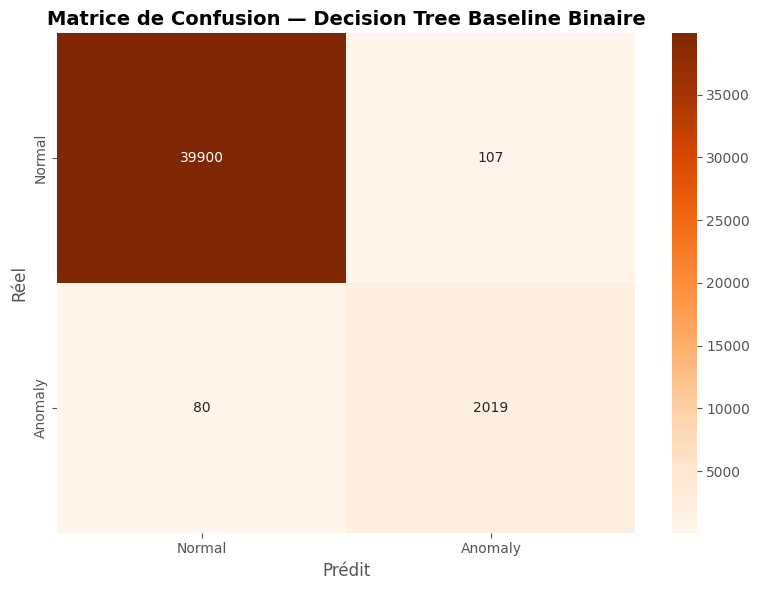

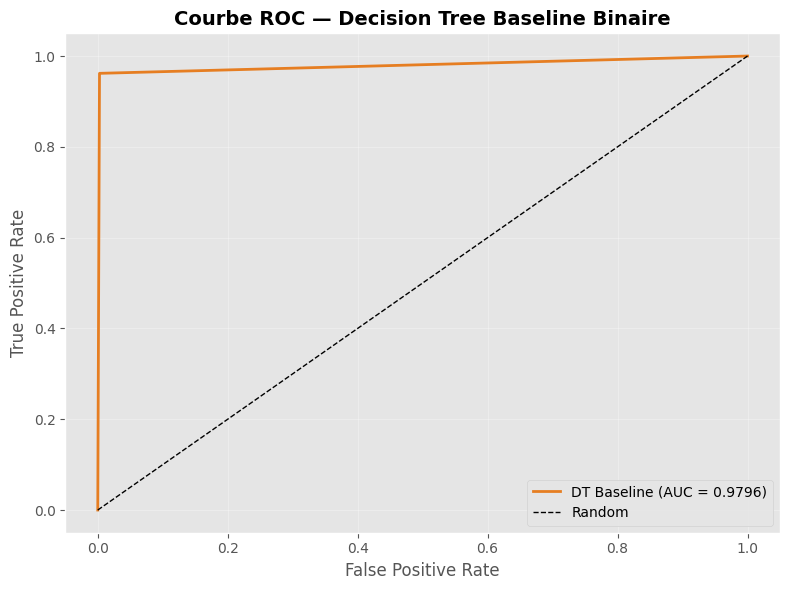


🌳 Caractéristiques de l'arbre Baseline:
   Profondeur max:     35
   Nombre de feuilles: 598
   Features utilisées: 16


In [66]:
# =====================================================================
# 7.0.1 Decision Tree Baseline — Classification Binaire — SANS GridSearch
# =====================================================================
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)
import time

# --- Modèle Baseline avec paramètres par défaut ---
print("="*70)
print("DECISION TREE BASELINE — CLASSIFICATION BINAIRE (Données brutes)")
print("="*70)

dt_baseline_b = DecisionTreeClassifier(random_state=42)

print(f"\nParamètres par défaut:")
print(f"   criterion:    {dt_baseline_b.criterion}")
print(f"   max_depth:    {dt_baseline_b.max_depth}")
print(f"   min_samples_split: {dt_baseline_b.min_samples_split}")
print(f"   min_samples_leaf:  {dt_baseline_b.min_samples_leaf}")

# --- Entraînement ---
start_time = time.time()
dt_baseline_b.fit(X_train_b, y1_train)
train_time = time.time() - start_time
print(f"\n✅ Entraînement terminé en {train_time:.2f}s")

# --- Prédictions ---
y1_pred_baseline = dt_baseline_b.predict(X_test_b)
y1_proba_baseline = dt_baseline_b.predict_proba(X_test_b)[:, 1]

# --- Métriques d'évaluation ---
acc_baseline = accuracy_score(y1_test, y1_pred_baseline)
prec_baseline = precision_score(y1_test, y1_pred_baseline)
rec_baseline = recall_score(y1_test, y1_pred_baseline)
f1_baseline = f1_score(y1_test, y1_pred_baseline)
auc_baseline = roc_auc_score(y1_test, y1_proba_baseline)

print(f"\n{'='*70}")
print("RÉSULTATS BASELINE — Classification Binaire (Données brutes)")
print("="*70)
print(f"\n  Accuracy:  {acc_baseline:.4f}")
print(f"  Precision: {prec_baseline:.4f}")
print(f"  Recall:    {rec_baseline:.4f}")
print(f"  F1-Score:  {f1_baseline:.4f}")
print(f"  ROC-AUC:   {auc_baseline:.4f}")

print(f"\n📊 Classification Report:")
print(classification_report(y1_test, y1_pred_baseline, target_names=['Normal', 'Anomaly']))

# --- Matrice de confusion ---
cm_baseline = confusion_matrix(y1_test, y1_pred_baseline)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'])
plt.title('Matrice de Confusion — Decision Tree Baseline Binaire', fontsize=14, fontweight='bold')
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.tight_layout()
plt.show()

# --- Courbe ROC ---
fpr_bl, tpr_bl, _ = roc_curve(y1_test, y1_proba_baseline)

plt.figure(figsize=(8, 6))
plt.plot(fpr_bl, tpr_bl, color='#e67e22', linewidth=2, label=f'DT Baseline (AUC = {auc_baseline:.4f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Courbe ROC — Decision Tree Baseline Binaire', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# --- Caractéristiques de l'arbre ---
print(f"\n🌳 Caractéristiques de l'arbre Baseline:")
print(f"   Profondeur max:     {dt_baseline_b.get_depth()}")
print(f"   Nombre de feuilles: {dt_baseline_b.get_n_leaves()}")
print(f"   Features utilisées: {dt_baseline_b.n_features_in_}")

## 7.0 Baseline — Classification Multi-classes (Types d'anomalies)

DECISION TREE BASELINE — CLASSIFICATION MULTI-CLASSES (Données brutes)

Paramètres par défaut:
   criterion:    gini
   max_depth:    None
   min_samples_split: 2
   min_samples_leaf:  1

✅ Entraînement terminé en 3.24s

RÉSULTATS BASELINE — Classification Multi-classes (Données brutes)

  Accuracy:           0.9946
  Precision (weighted): 0.9947
  Recall (weighted):    0.9946
  F1-Score (weighted):  0.9946

📊 Classification Report:
                    precision    recall  f1-score   support

    backhaul_issue       0.97      1.00      0.98       260
  handover_failure       1.00      1.00      1.00       252
  hardware_failure       0.98      0.98      0.98       266
      interference       0.92      0.90      0.91       269
network_congestion       0.99      0.96      0.97       259
            normal       1.00      1.00      1.00     40007
          overload       0.89      0.92      0.91       265
   security_attack       0.97      0.99      0.98       276
signal_degradation    

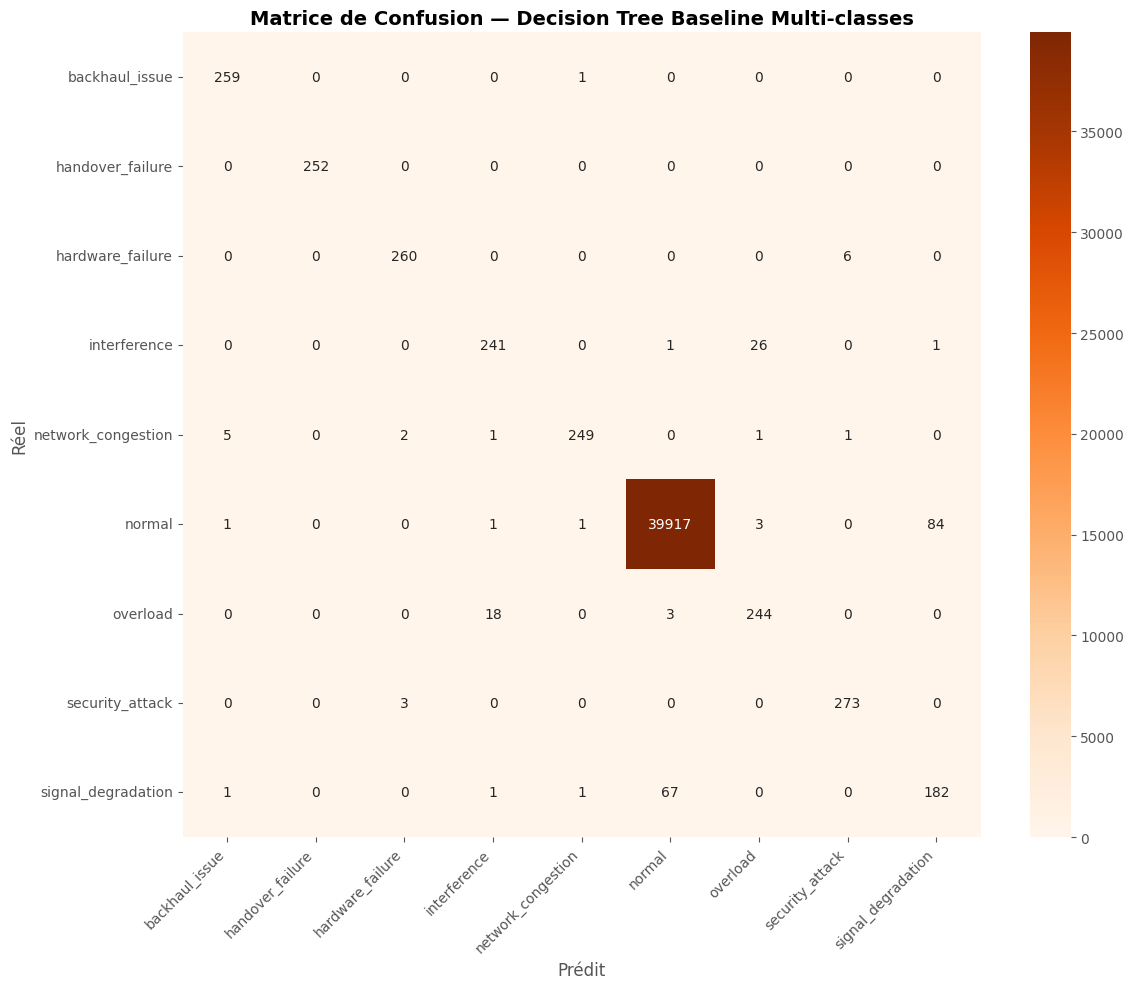


🌳 Caractéristiques de l'arbre Baseline Multi-classes:
   Profondeur max:     38
   Nombre de feuilles: 775
   Features utilisées: 16

📋 RÉSUMÉ BASELINE DECISION TREE (Paramètres par défaut)

  Métrique                     Binaire   Multi-classes
  --------------------------------------------------
  Accuracy                      0.9956          0.9946
  Precision                     0.9497          0.9947
  Recall                        0.9619          0.9946
  F1-Score                      0.9557          0.9946

⚠️  Ces résultats servent de RÉFÉRENCE pour évaluer l'amélioration
   apportée par l'optimisation des hyperparamètres (GridSearchCV).


In [67]:
# =====================================================================
# 7.0.2 Decision Tree Baseline — Classification Multi-classes — SANS GridSearch
# =====================================================================
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
import time

# --- Modèle Baseline Multi-classes avec paramètres par défaut ---
print("="*70)
print("DECISION TREE BASELINE — CLASSIFICATION MULTI-CLASSES (Données brutes)")
print("="*70)

dt_baseline_m = DecisionTreeClassifier(random_state=42)

print(f"\nParamètres par défaut:")
print(f"   criterion:    {dt_baseline_m.criterion}")
print(f"   max_depth:    {dt_baseline_m.max_depth}")
print(f"   min_samples_split: {dt_baseline_m.min_samples_split}")
print(f"   min_samples_leaf:  {dt_baseline_m.min_samples_leaf}")

# --- Entraînement ---
start_time = time.time()
dt_baseline_m.fit(X_train_m, y2_train)
train_time = time.time() - start_time
print(f"\n✅ Entraînement terminé en {train_time:.2f}s")

# --- Prédictions ---
y2_pred_baseline = dt_baseline_m.predict(X_test_m)

# --- Métriques d'évaluation ---
acc_baseline_m = accuracy_score(y2_test, y2_pred_baseline)
prec_baseline_m = precision_score(y2_test, y2_pred_baseline, average='weighted')
rec_baseline_m = recall_score(y2_test, y2_pred_baseline, average='weighted')
f1_baseline_m = f1_score(y2_test, y2_pred_baseline, average='weighted')

print(f"\n{'='*70}")
print("RÉSULTATS BASELINE — Classification Multi-classes (Données brutes)")
print("="*70)
print(f"\n  Accuracy:           {acc_baseline_m:.4f}")
print(f"  Precision (weighted): {prec_baseline_m:.4f}")
print(f"  Recall (weighted):    {rec_baseline_m:.4f}")
print(f"  F1-Score (weighted):  {f1_baseline_m:.4f}")

print(f"\n📊 Classification Report:")
print(classification_report(y2_test, y2_pred_baseline, target_names=le_anomaly.classes_))

# --- Matrice de confusion ---
cm_baseline_m = confusion_matrix(y2_test, y2_pred_baseline)
plt.figure(figsize=(12, 10))
sns.heatmap(cm_baseline_m, annot=True, fmt='d', cmap='Oranges',
            xticklabels=le_anomaly.classes_,
            yticklabels=le_anomaly.classes_)
plt.title('Matrice de Confusion — Decision Tree Baseline Multi-classes', fontsize=14, fontweight='bold')
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# --- Caractéristiques de l'arbre ---
print(f"\n🌳 Caractéristiques de l'arbre Baseline Multi-classes:")
print(f"   Profondeur max:     {dt_baseline_m.get_depth()}")
print(f"   Nombre de feuilles: {dt_baseline_m.get_n_leaves()}")
print(f"   Features utilisées: {dt_baseline_m.n_features_in_}")

# --- Résumé Baseline ---
print(f"\n{'='*70}")
print("📋 RÉSUMÉ BASELINE DECISION TREE (Paramètres par défaut)")
print("="*70)
print(f"\n  {'Métrique':<25} {'Binaire':>10} {'Multi-classes':>15}")
print(f"  {'-'*50}")
print(f"  {'Accuracy':<25} {acc_baseline:>10.4f} {acc_baseline_m:>15.4f}")
print(f"  {'Precision':<25} {prec_baseline:>10.4f} {prec_baseline_m:>15.4f}")
print(f"  {'Recall':<25} {rec_baseline:>10.4f} {rec_baseline_m:>15.4f}")
print(f"  {'F1-Score':<25} {f1_baseline:>10.4f} {f1_baseline_m:>15.4f}")
print(f"\n⚠️  Ces résultats servent de RÉFÉRENCE pour évaluer l'amélioration")
print(f"   apportée par l'optimisation des hyperparamètres (GridSearchCV).")

## 7. Modélisation — Decision Tree 


### 7.1 Classification Binaire — Decision Tree (Normal vs Anomaly)

In [68]:
# =====================================================================
# 7.1.1 Decision Tree — Binary Classification (Default Parameters)
# =====================================================================
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)
import time

print("="*70)
print("DECISION TREE — CLASSIFICATION BINAIRE (Normal vs Anomaly)")
print("="*70)

# Train the model with default parameters
start_time = time.time()
dt_binary = DecisionTreeClassifier(random_state=42)
dt_binary.fit(X_train_b, y1_train)
train_time = time.time() - start_time

# Predictions
start_pred = time.time()
y1_pred = dt_binary.predict(X_test_b)
y1_pred_proba = dt_binary.predict_proba(X_test_b)[:, 1]
pred_time = time.time() - start_pred

# Metrics
acc = accuracy_score(y1_test, y1_pred)
prec = precision_score(y1_test, y1_pred)
rec = recall_score(y1_test, y1_pred)
f1 = f1_score(y1_test, y1_pred)
roc_auc = roc_auc_score(y1_test, y1_pred_proba)

print(f"\n⏱️  Training time:   {train_time:.4f}s")
print(f"⏱️  Prediction time: {pred_time:.4f}s")
print(f"\n📊 METRICS (Default Parameters):")
print(f"   Accuracy:  {acc:.4f}  ({acc*100:.2f}%)")
print(f"   Precision: {prec:.4f}")
print(f"   Recall:    {rec:.4f}")
print(f"   F1-Score:  {f1:.4f}")
print(f"   ROC-AUC:   {roc_auc:.4f}")

print(f"\n📋 Classification Report:")
print(classification_report(y1_test, y1_pred, target_names=['Normal', 'Anomaly']))

# Tree characteristics
print(f"\n🌳 Tree Characteristics:")
print(f"   Max depth:     {dt_binary.get_depth()}")
print(f"   Number of leaves: {dt_binary.get_n_leaves()}")
print(f"   Number of features used: {dt_binary.n_features_in_}")

DECISION TREE — CLASSIFICATION BINAIRE (Normal vs Anomaly)

⏱️  Training time:   3.2776s
⏱️  Prediction time: 0.0159s

📊 METRICS (Default Parameters):
   Accuracy:  0.9956  (99.56%)
   Precision: 0.9497
   Recall:    0.9619
   F1-Score:  0.9557
   ROC-AUC:   0.9796

📋 Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     40007
     Anomaly       0.95      0.96      0.96      2099

    accuracy                           1.00     42106
   macro avg       0.97      0.98      0.98     42106
weighted avg       1.00      1.00      1.00     42106


🌳 Tree Characteristics:
   Max depth:     35
   Number of leaves: 598
   Number of features used: 16


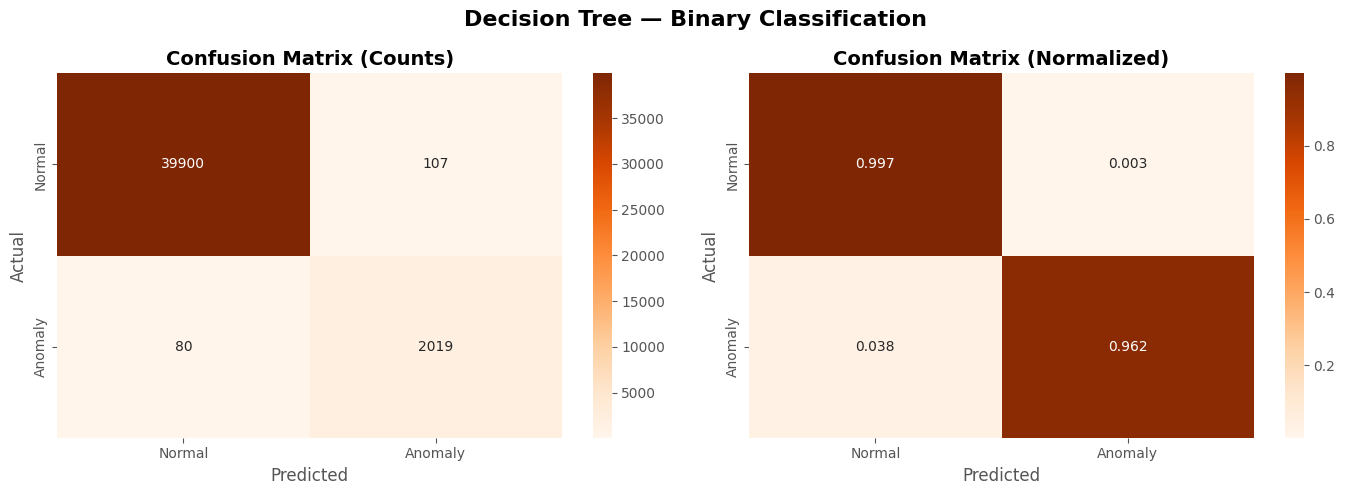


📊 Confusion Matrix Details:
   True Negatives (TN):  39,900  — Normal correctement classé
   False Positives (FP): 107  — Normal classé comme Anomaly (fausse alerte)
   False Negatives (FN): 80  — Anomaly classé comme Normal (anomalie manquée)
   True Positives (TP):  2,019  — Anomaly correctement détecté


In [69]:
# =====================================================================
# 7.1.2 Confusion Matrix — Binary Classification
# =====================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix (counts)
cm = confusion_matrix(y1_test, y1_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=axes[0],
            xticklabels=['Normal', 'Anomaly'], yticklabels=['Normal', 'Anomaly'])
axes[0].set_title('Confusion Matrix (Counts)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Confusion Matrix (normalized)
cm_norm = confusion_matrix(y1_test, y1_pred, normalize='true')
sns.heatmap(cm_norm, annot=True, fmt='.3f', cmap='Oranges', ax=axes[1],
            xticklabels=['Normal', 'Anomaly'], yticklabels=['Normal', 'Anomaly'])
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.suptitle('Decision Tree — Binary Classification', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Detailed interpretation
tn, fp, fn, tp = cm.ravel()
print(f"\n📊 Confusion Matrix Details:")
print(f"   True Negatives (TN):  {tn:,}  — Normal correctement classé")
print(f"   False Positives (FP): {fp:,}  — Normal classé comme Anomaly (fausse alerte)")
print(f"   False Negatives (FN): {fn:,}  — Anomaly classé comme Normal (anomalie manquée)")
print(f"   True Positives (TP):  {tp:,}  — Anomaly correctement détecté")

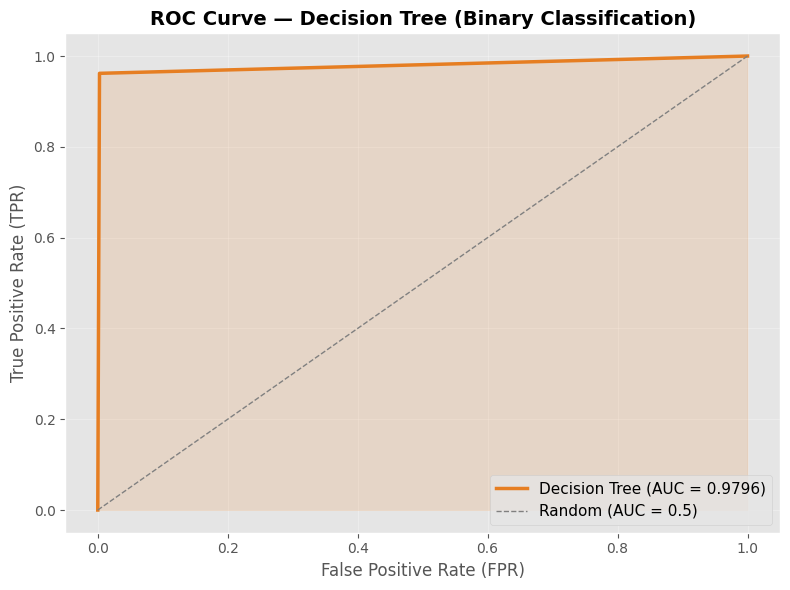


📍 Optimal Threshold (Youden's J): 1.0000
   TPR at optimal: 0.9619
   FPR at optimal: 0.0027


In [70]:
# =====================================================================
# 7.1.3 ROC Curve — Binary Classification
# =====================================================================

fpr, tpr, thresholds = roc_curve(y1_test, y1_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#e67e22', linewidth=2.5, label=f'Decision Tree (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1, label='Random (AUC = 0.5)')
plt.fill_between(fpr, tpr, alpha=0.15, color='#e67e22')

plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.title('ROC Curve — Decision Tree (Binary Classification)', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Optimal threshold (Youden's J statistic)
j_scores = tpr - fpr
best_idx = np.argmax(j_scores)
best_threshold = thresholds[best_idx]
print(f"\n📍 Optimal Threshold (Youden's J): {best_threshold:.4f}")
print(f"   TPR at optimal: {tpr[best_idx]:.4f}")
print(f"   FPR at optimal: {fpr[best_idx]:.4f}")

CROSS-VALIDATION (5-Fold) — Decision Tree Binary

   Accuracy:  0.9957 ± 0.0003  [0.99608134 0.9957251  0.99530935 0.99569529 0.99587341]
   F1-Score:  0.9574 ± 0.0024  [0.96073766 0.95749705 0.95347468 0.95688373 0.9585693 ]
   ROC-AUC:   0.9795 ± 0.0014  [0.97960805 0.98139456 0.98060121 0.97798257 0.97779413]


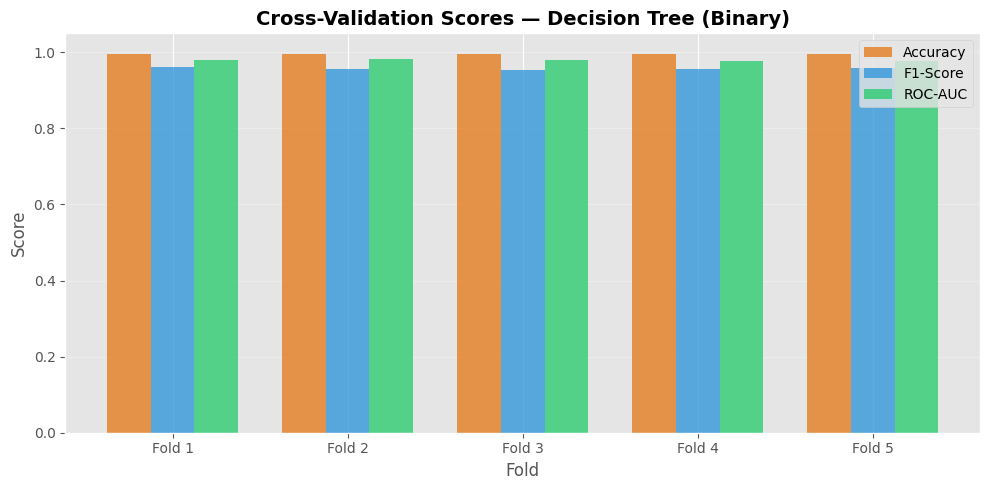

In [71]:
# =====================================================================
# 7.1.4 Cross-Validation — Binary Classification
# =====================================================================
from sklearn.model_selection import cross_val_score

print("="*70)
print("CROSS-VALIDATION (5-Fold) — Decision Tree Binary")
print("="*70)

cv_scores_acc = cross_val_score(dt_binary, X_train_b, y1_train, cv=5, scoring='accuracy')
cv_scores_f1 = cross_val_score(dt_binary, X_train_b, y1_train, cv=5, scoring='f1')
cv_scores_roc = cross_val_score(dt_binary, X_train_b, y1_train, cv=5, scoring='roc_auc')

print(f"\n   Accuracy:  {cv_scores_acc.mean():.4f} ± {cv_scores_acc.std():.4f}  {cv_scores_acc}")
print(f"   F1-Score:  {cv_scores_f1.mean():.4f} ± {cv_scores_f1.std():.4f}  {cv_scores_f1}")
print(f"   ROC-AUC:   {cv_scores_roc.mean():.4f} ± {cv_scores_roc.std():.4f}  {cv_scores_roc}")

# Visualization
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(1, 6)
width = 0.25
ax.bar(x - width, cv_scores_acc, width, label='Accuracy', color='#e67e22', alpha=0.8)
ax.bar(x, cv_scores_f1, width, label='F1-Score', color='#3498db', alpha=0.8)
ax.bar(x + width, cv_scores_roc, width, label='ROC-AUC', color='#2ecc71', alpha=0.8)
ax.set_xlabel('Fold')
ax.set_ylabel('Score')
ax.set_title('Cross-Validation Scores — Decision Tree (Binary)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f'Fold {i}' for i in range(1, 6)])
ax.legend()
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 7.2 Hyperparameter Tuning — Decision Tree (GridSearchCV)

In [72]:
# =====================================================================
# 7.2.1 GridSearchCV — Optimisation des hyperparamètres (Binary)
# =====================================================================
from sklearn.model_selection import GridSearchCV

print("="*70)
print("GRIDSEARCHCV — DECISION TREE (Binary Classification)")
print("="*70)

param_grid = {
    'max_depth': [5, 10, 15, 20, 25, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'criterion': ['gini', 'entropy'],
    'max_features': ['sqrt', 'log2', None]
}

print(f"\n🔍 Search space: {param_grid}")
print(f"   Total combinations: {np.prod([len(v) for v in param_grid.values()])}")

start_gs = time.time()
grid_search_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)
grid_search_dt.fit(X_train_b, y1_train)
gs_time = time.time() - start_gs

print(f"\n⏱️  GridSearchCV time: {gs_time:.2f}s")
print(f"\n🏆 Best Parameters:")
for param, value in grid_search_dt.best_params_.items():
    print(f"   {param}: {value}")
print(f"\n   Best F1-Score (CV): {grid_search_dt.best_score_:.4f}")

GRIDSEARCHCV — DECISION TREE (Binary Classification)

🔍 Search space: {'max_depth': [5, 10, 15, 20, 25, None], 'min_samples_split': [2, 5, 10, 20], 'min_samples_leaf': [1, 2, 5, 10], 'criterion': ['gini', 'entropy'], 'max_features': ['sqrt', 'log2', None]}
   Total combinations: 576
Fitting 5 folds for each of 576 candidates, totalling 2880 fits

⏱️  GridSearchCV time: 500.87s

🏆 Best Parameters:
   criterion: entropy
   max_depth: 15
   max_features: None
   min_samples_leaf: 10
   min_samples_split: 2

   Best F1-Score (CV): 0.9779


In [73]:
# =====================================================================
# 7.2.2 Evaluate Optimized Decision Tree (Binary)
# =====================================================================

print("="*70)
print("DECISION TREE OPTIMISÉ — RÉSULTATS (Binary Classification)")
print("="*70)

# Best model
dt_binary_best = grid_search_dt.best_estimator_

# Predictions with optimized model
y1_pred_best = dt_binary_best.predict(X_test_b)
y1_pred_proba_best = dt_binary_best.predict_proba(X_test_b)[:, 1]

# Metrics
acc_best = accuracy_score(y1_test, y1_pred_best)
prec_best = precision_score(y1_test, y1_pred_best)
rec_best = recall_score(y1_test, y1_pred_best)
f1_best = f1_score(y1_test, y1_pred_best)
roc_auc_best = roc_auc_score(y1_test, y1_pred_proba_best)

print(f"\n📊 METRICS (Optimized):")
print(f"   Accuracy:  {acc_best:.4f}  ({acc_best*100:.2f}%)")
print(f"   Precision: {prec_best:.4f}")
print(f"   Recall:    {rec_best:.4f}")
print(f"   F1-Score:  {f1_best:.4f}")
print(f"   ROC-AUC:   {roc_auc_best:.4f}")

# Comparison: Default vs Optimized
print(f"\n📈 COMPARISON (Default vs Optimized):")
print(f"   {'Metric':<12} {'Default':>10} {'Optimized':>10} {'Δ':>10}")
print(f"   {'-'*44}")
print(f"   {'Accuracy':<12} {acc:>10.4f} {acc_best:>10.4f} {acc_best-acc:>+10.4f}")
print(f"   {'Precision':<12} {prec:>10.4f} {prec_best:>10.4f} {prec_best-prec:>+10.4f}")
print(f"   {'Recall':<12} {rec:>10.4f} {rec_best:>10.4f} {rec_best-rec:>+10.4f}")
print(f"   {'F1-Score':<12} {f1:>10.4f} {f1_best:>10.4f} {f1_best-f1:>+10.4f}")
print(f"   {'ROC-AUC':<12} {roc_auc:>10.4f} {roc_auc_best:>10.4f} {roc_auc_best-roc_auc:>+10.4f}")

print(f"\n📋 Classification Report (Optimized):")
print(classification_report(y1_test, y1_pred_best, target_names=['Normal', 'Anomaly']))

# Tree characteristics
print(f"\n🌳 Optimized Tree Characteristics:")
print(f"   Max depth:        {dt_binary_best.get_depth()}")
print(f"   Number of leaves: {dt_binary_best.get_n_leaves()}")

DECISION TREE OPTIMISÉ — RÉSULTATS (Binary Classification)

📊 METRICS (Optimized):
   Accuracy:  0.9979  (99.79%)
   Precision: 0.9956
   Recall:    0.9624
   F1-Score:  0.9787
   ROC-AUC:   0.9925

📈 COMPARISON (Default vs Optimized):
   Metric          Default  Optimized          Δ
   --------------------------------------------
   Accuracy         0.9956     0.9979    +0.0024
   Precision        0.9497     0.9956    +0.0459
   Recall           0.9619     0.9624    +0.0005
   F1-Score         0.9557     0.9787    +0.0229
   ROC-AUC          0.9796     0.9925    +0.0129

📋 Classification Report (Optimized):
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     40007
     Anomaly       1.00      0.96      0.98      2099

    accuracy                           1.00     42106
   macro avg       1.00      0.98      0.99     42106
weighted avg       1.00      1.00      1.00     42106


🌳 Optimized Tree Characteristics:
   Max depth:        1

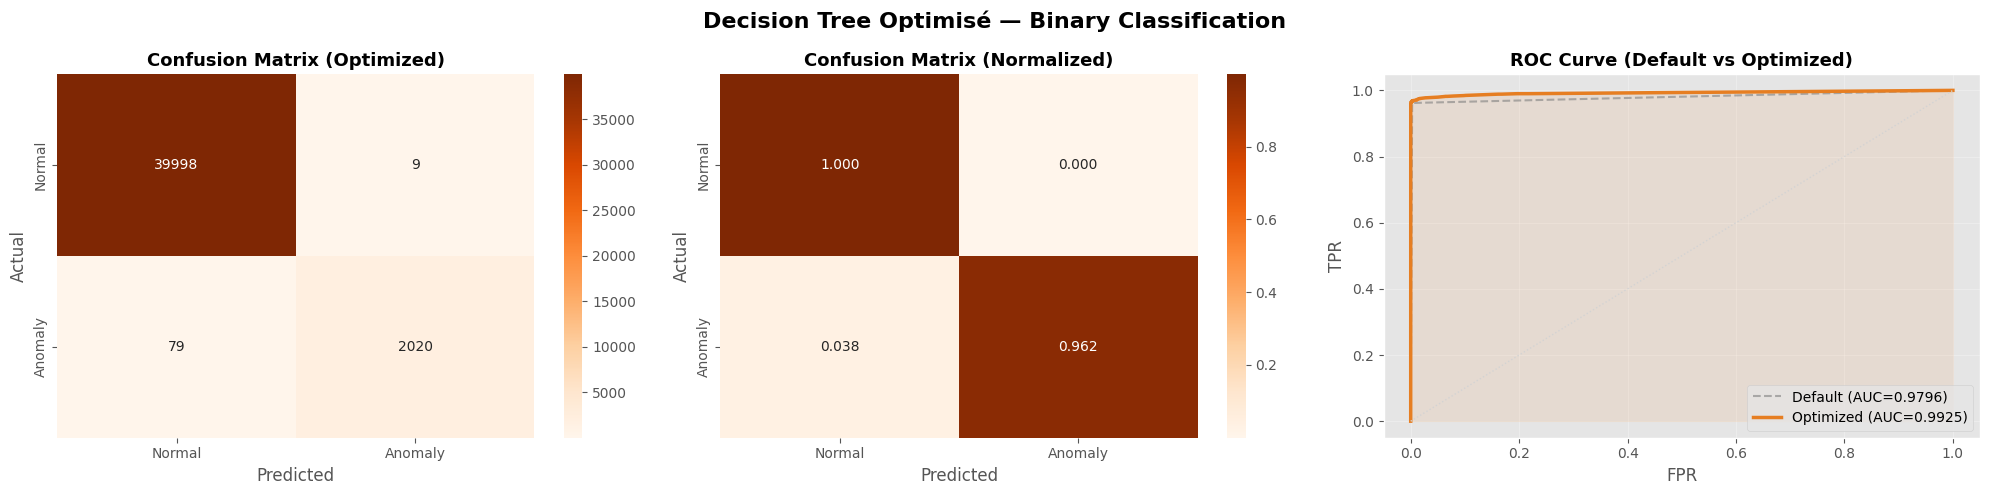

In [74]:
# =====================================================================
# 7.2.3 Confusion Matrix & ROC — Optimized Binary Model
# =====================================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Confusion Matrix (counts)
cm_best = confusion_matrix(y1_test, y1_pred_best)
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Oranges', ax=axes[0],
            xticklabels=['Normal', 'Anomaly'], yticklabels=['Normal', 'Anomaly'])
axes[0].set_title('Confusion Matrix (Optimized)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Confusion Matrix (normalized)
cm_best_norm = confusion_matrix(y1_test, y1_pred_best, normalize='true')
sns.heatmap(cm_best_norm, annot=True, fmt='.3f', cmap='Oranges', ax=axes[1],
            xticklabels=['Normal', 'Anomaly'], yticklabels=['Normal', 'Anomaly'])
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

# ROC Curve comparison
fpr_best, tpr_best, _ = roc_curve(y1_test, y1_pred_proba_best)
axes[2].plot(fpr, tpr, color='gray', linewidth=1.5, linestyle='--', 
             label=f'Default (AUC={roc_auc:.4f})', alpha=0.6)
axes[2].plot(fpr_best, tpr_best, color='#e67e22', linewidth=2.5, 
             label=f'Optimized (AUC={roc_auc_best:.4f})')
axes[2].plot([0, 1], [0, 1], color='lightgray', linestyle=':', linewidth=1)
axes[2].fill_between(fpr_best, tpr_best, alpha=0.1, color='#e67e22')
axes[2].set_xlabel('FPR')
axes[2].set_ylabel('TPR')
axes[2].set_title('ROC Curve (Default vs Optimized)', fontsize=13, fontweight='bold')
axes[2].legend(loc='lower right')
axes[2].grid(True, alpha=0.3)

plt.suptitle('Decision Tree Optimisé — Binary Classification', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

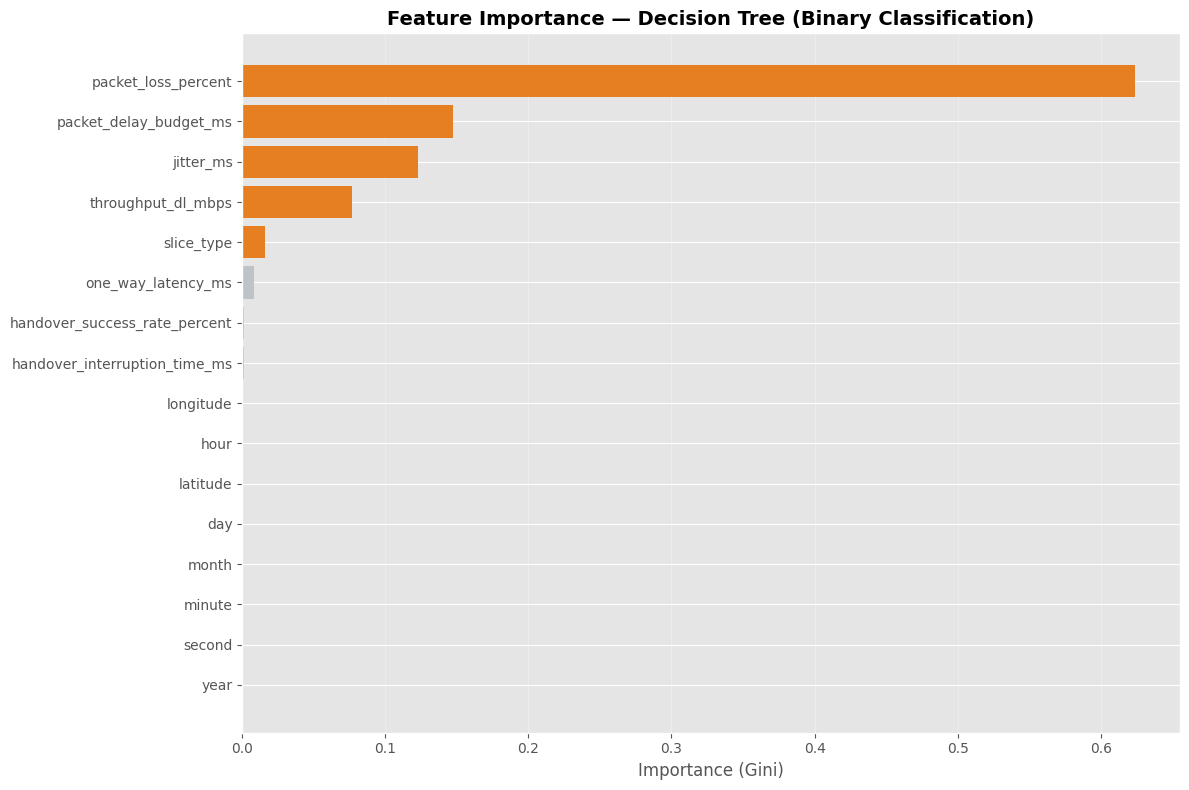

🏆 Top 10 Features:
   packet_loss_percent                      0.6242
   packet_delay_budget_ms                   0.1471
   jitter_ms                                0.1225
   throughput_dl_mbps                       0.0766
   slice_type                               0.0156
   one_way_latency_ms                       0.0081
   handover_success_rate_percent            0.0012
   handover_interruption_time_ms            0.0009
   longitude                                0.0009
   hour                                     0.0007

📊 Features with importance > 0.05: 4
📊 Features with importance ≈ 0:     9


In [75]:
# =====================================================================
# 7.2.4 Feature Importance — Decision Tree (Binary)
# =====================================================================

feature_importance = pd.DataFrame({
    'Feature': X_train_b.columns,
    'Importance': dt_binary_best.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(12, 8))
colors = ['#e67e22' if i < 5 else '#bdc3c7' for i in range(len(feature_importance))]
plt.barh(range(len(feature_importance)), feature_importance['Importance'].values, color=colors)
plt.yticks(range(len(feature_importance)), feature_importance['Feature'].values)
plt.xlabel('Importance (Gini)', fontsize=12)
plt.title('Feature Importance — Decision Tree (Binary Classification)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("🏆 Top 10 Features:")
for idx, row in feature_importance.head(10).iterrows():
    print(f"   {row['Feature']:<40} {row['Importance']:.4f}")

print(f"\n📊 Features with importance > 0.05: {(feature_importance['Importance'] > 0.05).sum()}")
print(f"📊 Features with importance ≈ 0:     {(feature_importance['Importance'] < 0.001).sum()}")

### 7.3 Classification Multi-Classes — Decision Tree (Anomaly Type)

In [76]:
# =====================================================================
# 7.3.1 Decision Tree — Multi-class (Default Parameters)
# =====================================================================

print("="*70)
print("DECISION TREE — CLASSIFICATION MULTI-CLASSES (Anomaly Type)")
print("="*70)

# Train with default parameters
start_time = time.time()
dt_multi = DecisionTreeClassifier(random_state=42)
dt_multi.fit(X_train_m, y2_train)
train_time_m = time.time() - start_time

# Predictions
y2_pred = dt_multi.predict(X_test_m)

# Metrics
acc_m = accuracy_score(y2_test, y2_pred)
prec_m = precision_score(y2_test, y2_pred, average='weighted')
rec_m = recall_score(y2_test, y2_pred, average='weighted')
f1_m = f1_score(y2_test, y2_pred, average='weighted')

print(f"\n⏱️  Training time: {train_time_m:.4f}s")
print(f"\n📊 METRICS (Default Parameters — Weighted Average):")
print(f"   Accuracy:          {acc_m:.4f}  ({acc_m*100:.2f}%)")
print(f"   Precision (weighted): {prec_m:.4f}")
print(f"   Recall (weighted):    {rec_m:.4f}")
print(f"   F1-Score (weighted):  {f1_m:.4f}")

print(f"\n📋 Classification Report:")
print(classification_report(y2_test, y2_pred, target_names=le_anomaly.classes_))

print(f"\n🌳 Tree Characteristics:")
print(f"   Max depth:        {dt_multi.get_depth()}")
print(f"   Number of leaves: {dt_multi.get_n_leaves()}")
print(f"   Number of classes: {dt_multi.n_classes_}")

DECISION TREE — CLASSIFICATION MULTI-CLASSES (Anomaly Type)

⏱️  Training time: 2.7568s

📊 METRICS (Default Parameters — Weighted Average):
   Accuracy:          0.9946  (99.46%)
   Precision (weighted): 0.9947
   Recall (weighted):    0.9946
   F1-Score (weighted):  0.9946

📋 Classification Report:
                    precision    recall  f1-score   support

    backhaul_issue       0.97      1.00      0.98       260
  handover_failure       1.00      1.00      1.00       252
  hardware_failure       0.98      0.98      0.98       266
      interference       0.92      0.90      0.91       269
network_congestion       0.99      0.96      0.97       259
            normal       1.00      1.00      1.00     40007
          overload       0.89      0.92      0.91       265
   security_attack       0.97      0.99      0.98       276
signal_degradation       0.68      0.72      0.70       252

          accuracy                           0.99     42106
         macro avg       0.93      0.

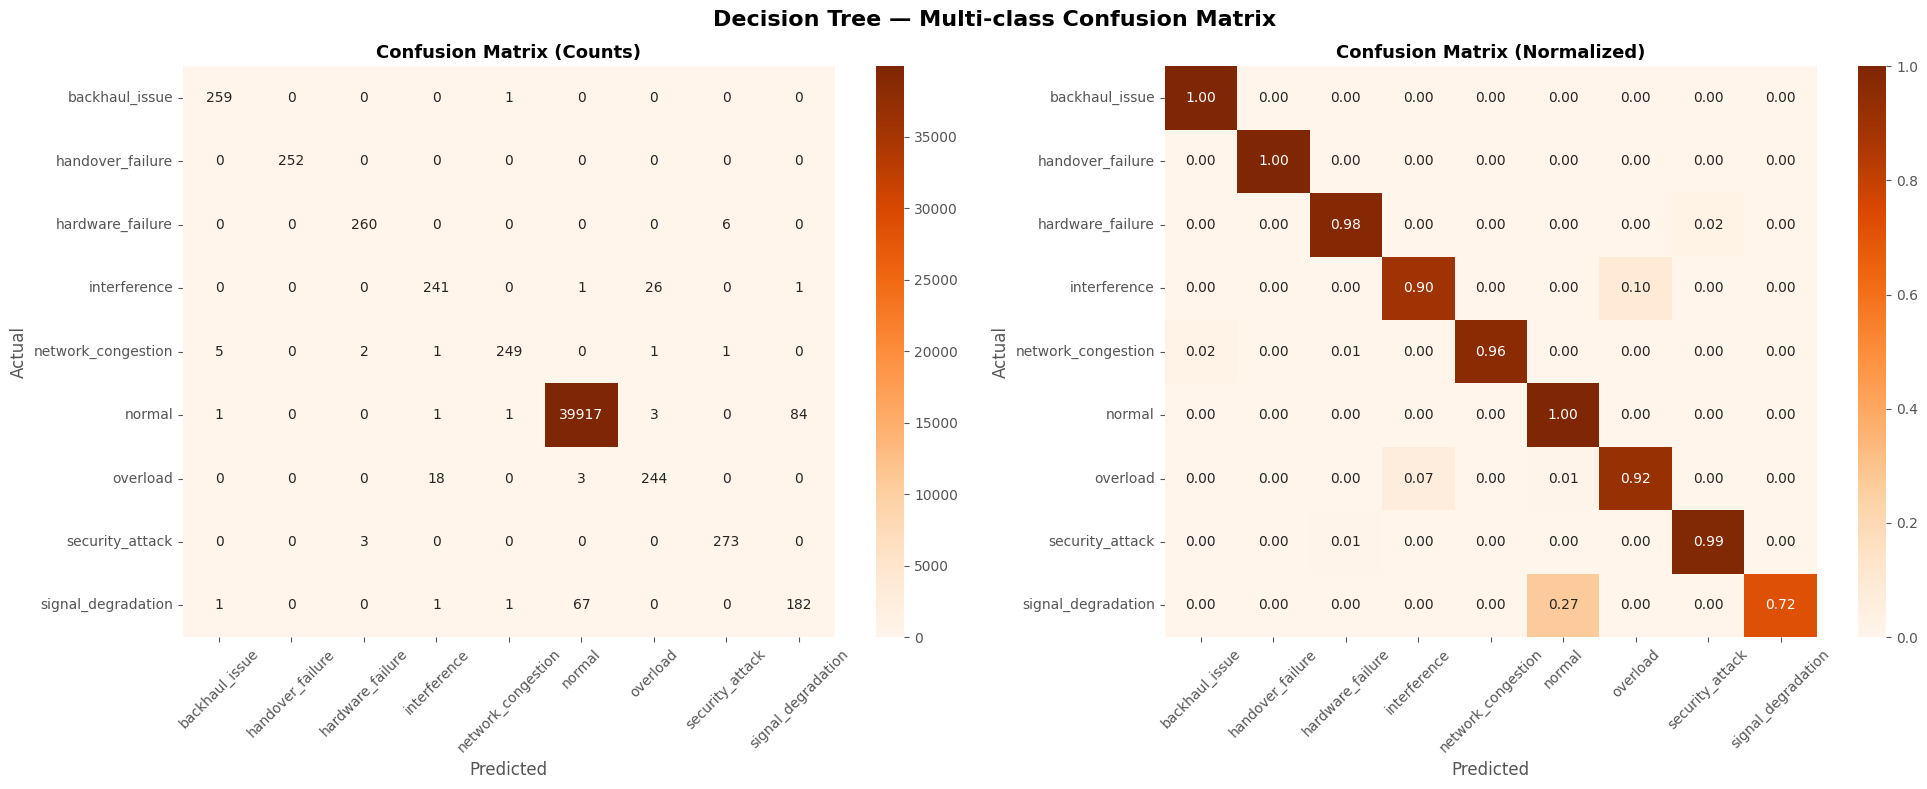

In [77]:
# =====================================================================
# 7.3.2 Confusion Matrix — Multi-class
# =====================================================================

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Confusion Matrix (counts)
cm_multi = confusion_matrix(y2_test, y2_pred)
sns.heatmap(cm_multi, annot=True, fmt='d', cmap='Oranges', ax=axes[0],
            xticklabels=le_anomaly.classes_, yticklabels=le_anomaly.classes_)
axes[0].set_title('Confusion Matrix (Counts)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].tick_params(axis='x', rotation=45)
axes[0].tick_params(axis='y', rotation=0)

# Confusion Matrix (normalized)
cm_multi_norm = confusion_matrix(y2_test, y2_pred, normalize='true')
sns.heatmap(cm_multi_norm, annot=True, fmt='.2f', cmap='Oranges', ax=axes[1],
            xticklabels=le_anomaly.classes_, yticklabels=le_anomaly.classes_)
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='y', rotation=0)

plt.suptitle('Decision Tree — Multi-class Confusion Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [78]:
# =====================================================================
# 7.3.3 GridSearchCV — Multi-class Optimization
# =====================================================================

print("="*70)
print("GRIDSEARCHCV — DECISION TREE (Multi-class Classification)")
print("="*70)

param_grid_multi = {
    'max_depth': [10, 15, 20, 25, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'criterion': ['gini', 'entropy'],
    'max_features': ['sqrt', 'log2', None]
}

start_gs_m = time.time()
grid_search_dt_multi = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_multi,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)
grid_search_dt_multi.fit(X_train_m, y2_train)
gs_time_m = time.time() - start_gs_m

print(f"\n⏱️  GridSearchCV time: {gs_time_m:.2f}s")
print(f"\n🏆 Best Parameters:")
for param, value in grid_search_dt_multi.best_params_.items():
    print(f"   {param}: {value}")
print(f"\n   Best F1-weighted (CV): {grid_search_dt_multi.best_score_:.4f}")

GRIDSEARCHCV — DECISION TREE (Multi-class Classification)
Fitting 5 folds for each of 270 candidates, totalling 1350 fits

⏱️  GridSearchCV time: 285.23s

🏆 Best Parameters:
   criterion: entropy
   max_depth: 10
   max_features: None
   min_samples_leaf: 1
   min_samples_split: 2

   Best F1-weighted (CV): 0.9962


In [79]:
# =====================================================================
# 7.3.4 Evaluate Optimized Decision Tree (Multi-class)
# =====================================================================

print("="*70)
print("DECISION TREE OPTIMISÉ — RÉSULTATS (Multi-class)")
print("="*70)

dt_multi_best = grid_search_dt_multi.best_estimator_

y2_pred_best = dt_multi_best.predict(X_test_m)

acc_m_best = accuracy_score(y2_test, y2_pred_best)
prec_m_best = precision_score(y2_test, y2_pred_best, average='weighted')
rec_m_best = recall_score(y2_test, y2_pred_best, average='weighted')
f1_m_best = f1_score(y2_test, y2_pred_best, average='weighted')

print(f"\n📊 METRICS (Optimized — Weighted Average):")
print(f"   Accuracy:             {acc_m_best:.4f}  ({acc_m_best*100:.2f}%)")
print(f"   Precision (weighted): {prec_m_best:.4f}")
print(f"   Recall (weighted):    {rec_m_best:.4f}")
print(f"   F1-Score (weighted):  {f1_m_best:.4f}")

# Comparison: Default vs Optimized
print(f"\n📈 COMPARISON (Default vs Optimized) — Multi-class:")
print(f"   {'Metric':<20} {'Default':>10} {'Optimized':>10} {'Δ':>10}")
print(f"   {'-'*52}")
print(f"   {'Accuracy':<20} {acc_m:>10.4f} {acc_m_best:>10.4f} {acc_m_best-acc_m:>+10.4f}")
print(f"   {'Precision (w)':<20} {prec_m:>10.4f} {prec_m_best:>10.4f} {prec_m_best-prec_m:>+10.4f}")
print(f"   {'Recall (w)':<20} {rec_m:>10.4f} {rec_m_best:>10.4f} {rec_m_best-rec_m:>+10.4f}")
print(f"   {'F1-Score (w)':<20} {f1_m:>10.4f} {f1_m_best:>10.4f} {f1_m_best-f1_m:>+10.4f}")

print(f"\n📋 Classification Report (Optimized):")
print(classification_report(y2_test, y2_pred_best, target_names=le_anomaly.classes_))

print(f"\n🌳 Optimized Tree Characteristics:")
print(f"   Max depth:        {dt_multi_best.get_depth()}")
print(f"   Number of leaves: {dt_multi_best.get_n_leaves()}")

DECISION TREE OPTIMISÉ — RÉSULTATS (Multi-class)

📊 METRICS (Optimized — Weighted Average):
   Accuracy:             0.9964  (99.64%)
   Precision (weighted): 0.9964
   Recall (weighted):    0.9964
   F1-Score (weighted):  0.9963

📈 COMPARISON (Default vs Optimized) — Multi-class:
   Metric                  Default  Optimized          Δ
   ----------------------------------------------------
   Accuracy                 0.9946     0.9964    +0.0019
   Precision (w)            0.9947     0.9964    +0.0017
   Recall (w)               0.9946     0.9964    +0.0019
   F1-Score (w)             0.9946     0.9963    +0.0017

📋 Classification Report (Optimized):
                    precision    recall  f1-score   support

    backhaul_issue       0.98      1.00      0.99       260
  handover_failure       1.00      1.00      1.00       252
  hardware_failure       1.00      0.99      0.99       266
      interference       0.91      0.87      0.89       269
network_congestion       1.00      0.9

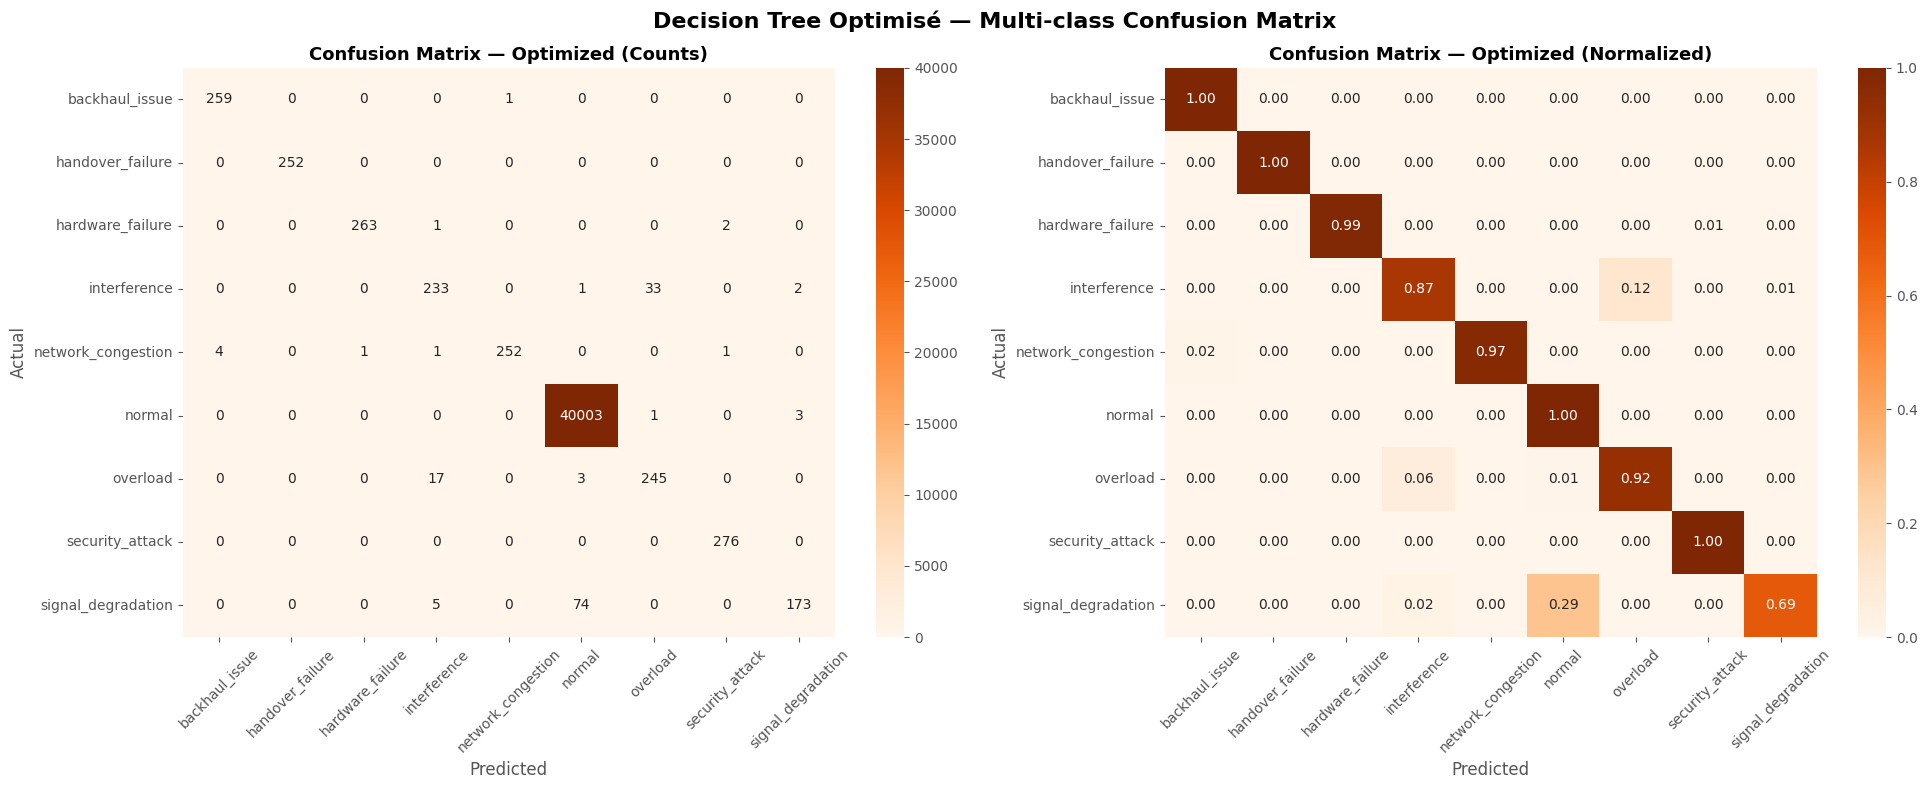

In [80]:
# =====================================================================
# 7.3.5 Confusion Matrix — Optimized Multi-class
# =====================================================================

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

cm_multi_best = confusion_matrix(y2_test, y2_pred_best)
sns.heatmap(cm_multi_best, annot=True, fmt='d', cmap='Oranges', ax=axes[0],
            xticklabels=le_anomaly.classes_, yticklabels=le_anomaly.classes_)
axes[0].set_title('Confusion Matrix — Optimized (Counts)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].tick_params(axis='x', rotation=45)

cm_multi_best_norm = confusion_matrix(y2_test, y2_pred_best, normalize='true')
sns.heatmap(cm_multi_best_norm, annot=True, fmt='.2f', cmap='Oranges', ax=axes[1],
            xticklabels=le_anomaly.classes_, yticklabels=le_anomaly.classes_)
axes[1].set_title('Confusion Matrix — Optimized (Normalized)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Decision Tree Optimisé — Multi-class Confusion Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

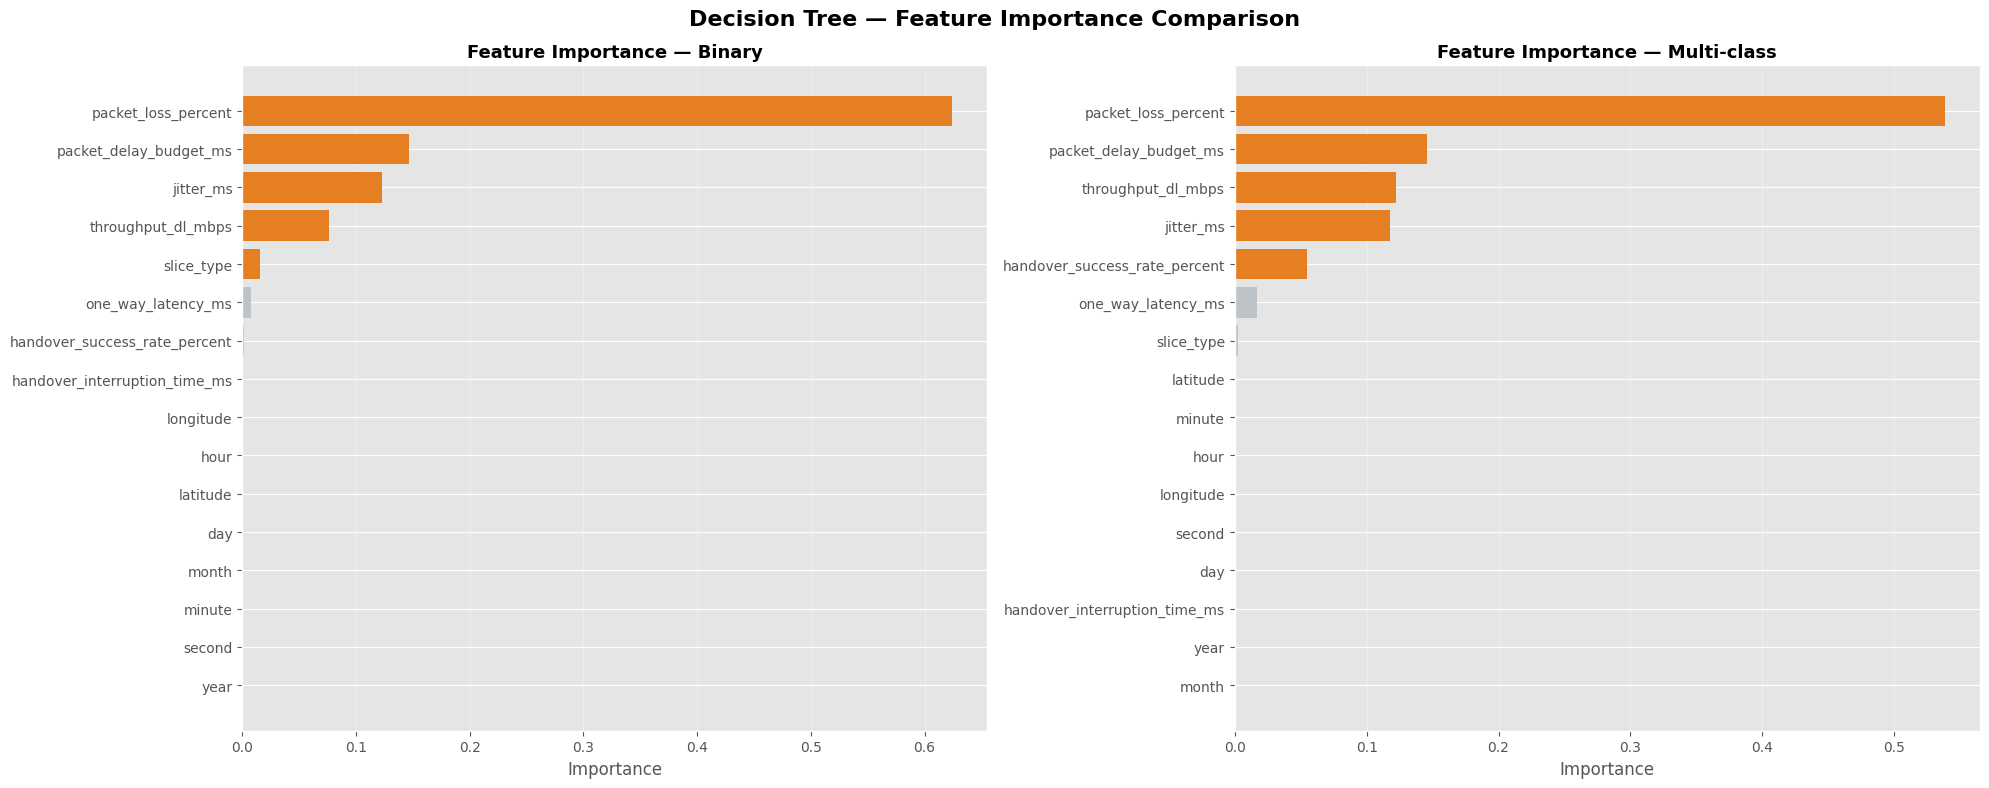


🏆 Top 5 Features (Multi-class):
   packet_loss_percent                      0.5381
   packet_delay_budget_ms                   0.1457
   throughput_dl_mbps                       0.1225
   jitter_ms                                0.1181
   handover_success_rate_percent            0.0550


In [81]:
# =====================================================================
# 7.3.6 Feature Importance — Multi-class
# =====================================================================

feature_importance_multi = pd.DataFrame({
    'Feature': X_train_m.columns,
    'Importance': dt_multi_best.feature_importances_
}).sort_values('Importance', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Binary Feature Importance
colors_b = ['#e67e22' if i < 5 else '#bdc3c7' for i in range(len(feature_importance))]
axes[0].barh(range(len(feature_importance)), feature_importance['Importance'].values, color=colors_b)
axes[0].set_yticks(range(len(feature_importance)))
axes[0].set_yticklabels(feature_importance['Feature'].values)
axes[0].set_xlabel('Importance')
axes[0].set_title('Feature Importance — Binary', fontsize=13, fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# Multi-class Feature Importance
colors_m = ['#e67e22' if i < 5 else '#bdc3c7' for i in range(len(feature_importance_multi))]
axes[1].barh(range(len(feature_importance_multi)), feature_importance_multi['Importance'].values, color=colors_m)
axes[1].set_yticks(range(len(feature_importance_multi)))
axes[1].set_yticklabels(feature_importance_multi['Feature'].values)
axes[1].set_xlabel('Importance')
axes[1].set_title('Feature Importance — Multi-class', fontsize=13, fontweight='bold')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('Decision Tree — Feature Importance Comparison', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n🏆 Top 5 Features (Multi-class):")
for idx, row in feature_importance_multi.head(5).iterrows():
    print(f"   {row['Feature']:<40} {row['Importance']:.4f}")

### 7.4 Analyse de l'Overfitting — Decision Tree

ANALYSE DE L'OVERFITTING — DECISION TREE

📊 Binary Classification:
   Metric            Train       Test        Gap
   --------------------------------------------
   Accuracy         0.9981     0.9979    +0.0002
   F1-Score         0.9803     0.9787    +0.0016

   ✅ Gap Train-Test = 0.0002 → Pas d'overfitting significatif

📊 Multi-class Classification:
   Metric            Train       Test        Gap
   --------------------------------------------
   Accuracy         0.9974     0.9964    +0.0010
   F1 (w)           0.9973     0.9963    +0.0010

   ✅ Gap Train-Test = 0.0010 → Pas d'overfitting significatif


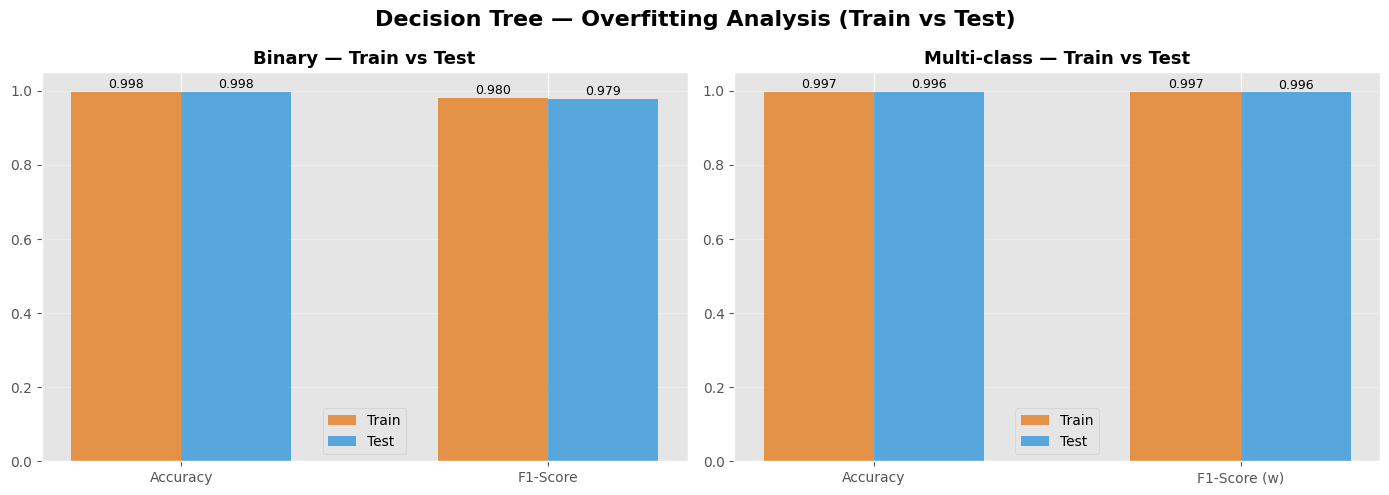

In [82]:
# =====================================================================
# 7.4.1 Overfitting Analysis — Train vs Test Performance
# =====================================================================

print("="*70)
print("ANALYSE DE L'OVERFITTING — DECISION TREE")
print("="*70)

# --- Binary Classification ---
y1_train_pred = dt_binary_best.predict(X_train_b)
acc_train_b = accuracy_score(y1_train, y1_train_pred)
f1_train_b = f1_score(y1_train, y1_train_pred)

print("\n📊 Binary Classification:")
print(f"   {'Metric':<12} {'Train':>10} {'Test':>10} {'Gap':>10}")
print(f"   {'-'*44}")
print(f"   {'Accuracy':<12} {acc_train_b:>10.4f} {acc_best:>10.4f} {acc_train_b-acc_best:>+10.4f}")
print(f"   {'F1-Score':<12} {f1_train_b:>10.4f} {f1_best:>10.4f} {f1_train_b-f1_best:>+10.4f}")

gap_b = acc_train_b - acc_best
if gap_b > 0.05:
    print(f"\n   ⚠️  Gap Train-Test = {gap_b:.4f} → Possible overfitting")
else:
    print(f"\n   ✅ Gap Train-Test = {gap_b:.4f} → Pas d'overfitting significatif")

# --- Multi-class Classification ---
y2_train_pred = dt_multi_best.predict(X_train_m)
acc_train_m = accuracy_score(y2_train, y2_train_pred)
f1_train_m = f1_score(y2_train, y2_train_pred, average='weighted')

print(f"\n📊 Multi-class Classification:")
print(f"   {'Metric':<12} {'Train':>10} {'Test':>10} {'Gap':>10}")
print(f"   {'-'*44}")
print(f"   {'Accuracy':<12} {acc_train_m:>10.4f} {acc_m_best:>10.4f} {acc_train_m-acc_m_best:>+10.4f}")
print(f"   {'F1 (w)':<12} {f1_train_m:>10.4f} {f1_m_best:>10.4f} {f1_train_m-f1_m_best:>+10.4f}")

gap_m = acc_train_m - acc_m_best
if gap_m > 0.05:
    print(f"\n   ⚠️  Gap Train-Test = {gap_m:.4f} → Possible overfitting")
else:
    print(f"\n   ✅ Gap Train-Test = {gap_m:.4f} → Pas d'overfitting significatif")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Binary
metrics_b = ['Accuracy', 'F1-Score']
train_vals_b = [acc_train_b, f1_train_b]
test_vals_b = [acc_best, f1_best]
x = np.arange(len(metrics_b))
axes[0].bar(x - 0.15, train_vals_b, 0.3, label='Train', color='#e67e22', alpha=0.8)
axes[0].bar(x + 0.15, test_vals_b, 0.3, label='Test', color='#3498db', alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics_b)
axes[0].set_ylim(0, 1.05)
axes[0].set_title('Binary — Train vs Test', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
for i, (tr, te) in enumerate(zip(train_vals_b, test_vals_b)):
    axes[0].text(i-0.15, tr+0.01, f'{tr:.3f}', ha='center', fontsize=9)
    axes[0].text(i+0.15, te+0.01, f'{te:.3f}', ha='center', fontsize=9)

# Multi-class
metrics_m = ['Accuracy', 'F1-Score (w)']
train_vals_m = [acc_train_m, f1_train_m]
test_vals_m = [acc_m_best, f1_m_best]
axes[1].bar(x - 0.15, train_vals_m, 0.3, label='Train', color='#e67e22', alpha=0.8)
axes[1].bar(x + 0.15, test_vals_m, 0.3, label='Test', color='#3498db', alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(metrics_m)
axes[1].set_ylim(0, 1.05)
axes[1].set_title('Multi-class — Train vs Test', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)
for i, (tr, te) in enumerate(zip(train_vals_m, test_vals_m)):
    axes[1].text(i-0.15, tr+0.01, f'{tr:.3f}', ha='center', fontsize=9)
    axes[1].text(i+0.15, te+0.01, f'{te:.3f}', ha='center', fontsize=9)

plt.suptitle('Decision Tree — Overfitting Analysis (Train vs Test)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### 7.5 Résumé Global — Decision Tree

In [83]:
# =====================================================================
# 7.5 RÉSUMÉ GLOBAL — DECISION TREE
# =====================================================================

print("="*80)
print("📋 RÉSUMÉ GLOBAL — DECISION TREE CLASSIFIER")
print("="*80)

print("\n" + "─"*80)
print("🔹 CLASSIFICATION BINAIRE (Normal vs Anomaly)")
print("─"*80)
print(f"\n   {'':30} {'Default':>12} {'Optimized':>12}")
print(f"   {'─'*56}")
print(f"   {'Accuracy':30} {acc:>12.4f} {acc_best:>12.4f}")
print(f"   {'Precision':30} {prec:>12.4f} {prec_best:>12.4f}")
print(f"   {'Recall':30} {rec:>12.4f} {rec_best:>12.4f}")
print(f"   {'F1-Score':30} {f1:>12.4f} {f1_best:>12.4f}")
print(f"   {'ROC-AUC':30} {roc_auc:>12.4f} {roc_auc_best:>12.4f}")
print(f"\n   Best Parameters (Binary):")
for p, v in grid_search_dt.best_params_.items():
    print(f"      {p}: {v}")

print("\n" + "─"*80)
print("🔹 CLASSIFICATION MULTI-CLASSES (Anomaly Type)")
print("─"*80)
print(f"\n   {'':30} {'Default':>12} {'Optimized':>12}")
print(f"   {'─'*56}")
print(f"   {'Accuracy':30} {acc_m:>12.4f} {acc_m_best:>12.4f}")
print(f"   {'Precision (weighted)':30} {prec_m:>12.4f} {prec_m_best:>12.4f}")
print(f"   {'Recall (weighted)':30} {rec_m:>12.4f} {rec_m_best:>12.4f}")
print(f"   {'F1-Score (weighted)':30} {f1_m:>12.4f} {f1_m_best:>12.4f}")
print(f"\n   Best Parameters (Multi-class):")
for p, v in grid_search_dt_multi.best_params_.items():
    print(f"      {p}: {v}")

print("\n" + "─"*80)
print("🔹 OVERFITTING ANALYSIS")
print("─"*80)
print(f"   Binary:      Train Acc = {acc_train_b:.4f} | Test Acc = {acc_best:.4f} | Gap = {gap_b:+.4f}")
print(f"   Multi-class: Train Acc = {acc_train_m:.4f} | Test Acc = {acc_m_best:.4f} | Gap = {gap_m:+.4f}")

print("\n" + "─"*80)
print("🔹 TREE CHARACTERISTICS")
print("─"*80)
print(f"   Binary (Optimized):      Depth = {dt_binary_best.get_depth()}, Leaves = {dt_binary_best.get_n_leaves()}")
print(f"   Multi-class (Optimized): Depth = {dt_multi_best.get_depth()}, Leaves = {dt_multi_best.get_n_leaves()}")

print("\n" + "─"*80)
print("🔹 TOP 5 FEATURES (Binary)")
print("─"*80)
for idx, row in feature_importance.head(5).iterrows():
    print(f"   {row['Feature']:<40} {row['Importance']:.4f}")

print("\n" + "="*80)
print("✅ MODÉLISATION DECISION TREE TERMINÉE")
print("="*80)

📋 RÉSUMÉ GLOBAL — DECISION TREE CLASSIFIER

────────────────────────────────────────────────────────────────────────────────
🔹 CLASSIFICATION BINAIRE (Normal vs Anomaly)
────────────────────────────────────────────────────────────────────────────────

                                       Default    Optimized
   ────────────────────────────────────────────────────────
   Accuracy                             0.9956       0.9979
   Precision                            0.9497       0.9956
   Recall                               0.9619       0.9624
   F1-Score                             0.9557       0.9787
   ROC-AUC                              0.9796       0.9925

   Best Parameters (Binary):
      criterion: entropy
      max_depth: 15
      max_features: None
      min_samples_leaf: 10
      min_samples_split: 2

────────────────────────────────────────────────────────────────────────────────
🔹 CLASSIFICATION MULTI-CLASSES (Anomaly Type)
──────────────────────────────────────────────